In [7]:
import pandas as pd

In [16]:
import pandas as pd
df = pd.read_csv(r"C:\Users\etiem\Downloads\E-Commerce\data.csv", encoding='cp1252')

In [18]:
df.duplicated() . sum ()

np.int64(5268)

In [19]:
df.shape

(541909, 8)

In [ ]:
# SECTION 1: LOAD AND FIRST LOOK

In [ ]:
# Q1: THE data has 541909 rows and 8 columns

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [ ]:
# Q2: column names include; InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country
I think the UnitPrice, Country, Description, Quantity, are important for this analysis because the description will give details about the type of product, UnitPrice will help determine the revenue (Income) or profits made by the business. The Country will halp advice which places the business owner should focus on more. Quantity wil help give information about what has been sold and how much is still available in stock

In [ ]:
# Q3: One row represents a single observation.

In [ ]:
# Q4: Columns containing numbers: 1.Quantity-int64 2.UnitPrice-float64 3.CustomerID-floar64: Columns containing text: 1.InvoiceNo 2.StockCode 3.Description 4.InvoiceDate 5.Country

In [21]:
df.isnull() . sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [ ]:
# SECTION 2: DATA CLEANING

In [ ]:
# Q5: The CustomerID has the highest missing values (135080)

In [37]:
df['Description'] = df['Description'].fillna('Unknown')
df['CustomerID'] = df.groupby('InvoiceNo')['CustomerID'].ffill().bfill()
grouped = df.groupby('InvoiceNo')                            
print(grouped.groups)

{'536365': [0, 1, 2, 3, 4, 5, 6], '536366': [7, 8], '536367': [9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], '536368': [21, 22, 23, 24], '536369': [25], '536370': [26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45], '536371': [46], '536372': [47, 48], '536373': [49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64], '536374': [65], '536375': [66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81], '536376': [82, 83], '536377': [84, 85], '536378': [86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104], '536380': [105], '536381': [106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140], '536382': [142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153], '536384': [155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167], '536385': [168, 169, 170, 171, 172, 173, 174], '536386': [175, 

In [38]:
df.isnull() . sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [39]:
df.duplicated() . sum()

np.int64(5268)

In [40]:
df.drop_duplicates()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [ ]:
# Q8: I did not notice any space n my dataset so left it as is.

In [ ]:
# SECTION 3: EXPLORATION AND GROUPBY

In [43]:
Country_orders=df.groupby("Country")["InvoiceNo"].nunique()
most_orders = Country_orders.idxmax()
print("Country with the most orders:",most_orders)

Country with the most orders: United Kingdom


In [44]:
Country_orders=df.groupby("Country")["InvoiceNo"].nunique()
Top_orders=Country_orders.max()

Total_orders=df["InvoiceNo"].nunique()
percentage=(Top_orders/Total_orders)*100
print("The Country with the most orders covers",percentage,"percent of the Total orders")

The Country with the most orders covers 90.7104247104247 percent of the Total orders


In [45]:
Best_sellers=df.groupby("Description")["Quantity"].sum()
Best_sellers=Best_sellers.sort_values(ascending=False)
Best_sellers.head(5)

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS    53847
JUMBO BAG RED RETROSPOT              47363
ASSORTED COLOUR BIRD ORNAMENT        36381
POPCORN HOLDER                       36334
PACK OF 72 RETROSPOT CAKE CASES      36039
Name: Quantity, dtype: int64

In [46]:
df["InvoiceDate"]=pd.to_datetime(df["InvoiceDate"],dayfirst=False)
df["month"]=df["InvoiceDate"].dt.month_name()
df["Income"]=df["Quantity"]*df["UnitPrice"]
monthly_sales=df.groupby("month")["Income"].sum()
highest_sales=monthly_sales.idxmax()
lowest_sales=monthly_sales.idxmin()
print("Month with the highest total sales revenue:",highest_sales)
print("Month with the lowest total sales revenue:",lowest_sales)

Month with the highest total sales revenue: November
Month with the lowest total sales revenue: April


In [47]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Income
count,541909.000000,541909,541909.000000,541909.000000,541909.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15275.374472,17.987795
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,-168469.600000
25%,1.000000,2011-03-28 11:34:00,1.250000,13895.000000,3.400000
50%,3.000000,2011-07-19 17:17:00,2.080000,15122.000000,9.750000
75%,10.000000,2011-10-19 11:27:00,4.130000,16777.000000,17.400000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,168469.600000
std,218.081158,NaN,96.759853,1719.104186,378.810824


In [48]:
order_value=df.groupby("InvoiceNo")["Income"].sum()
average_value=order_value.mean()
highest_value=order_value.max()
print("Average order value:",average_value)
print("Highest order value:",highest_value)

Average order value: 376.3609240926641
Highest order value: 168469.6


In [49]:
available_negative=(df["Quantity"]<0).any()
print(available_negative)
df[df["Quantity"]<0].shape[0]

True


10624

In [ ]:
# The presence of negative values in the data set indicates that some others were cancelled.

In [ ]:
# SECTION 4: VISUALIZATION

Country
United Kingdom    23494
Germany             603
France              461
EIRE                360
Belgium             119
Spain               105
Netherlands         101
Switzerland          74
Portugal             71
Australia            69
Name: InvoiceNo, dtype: int64


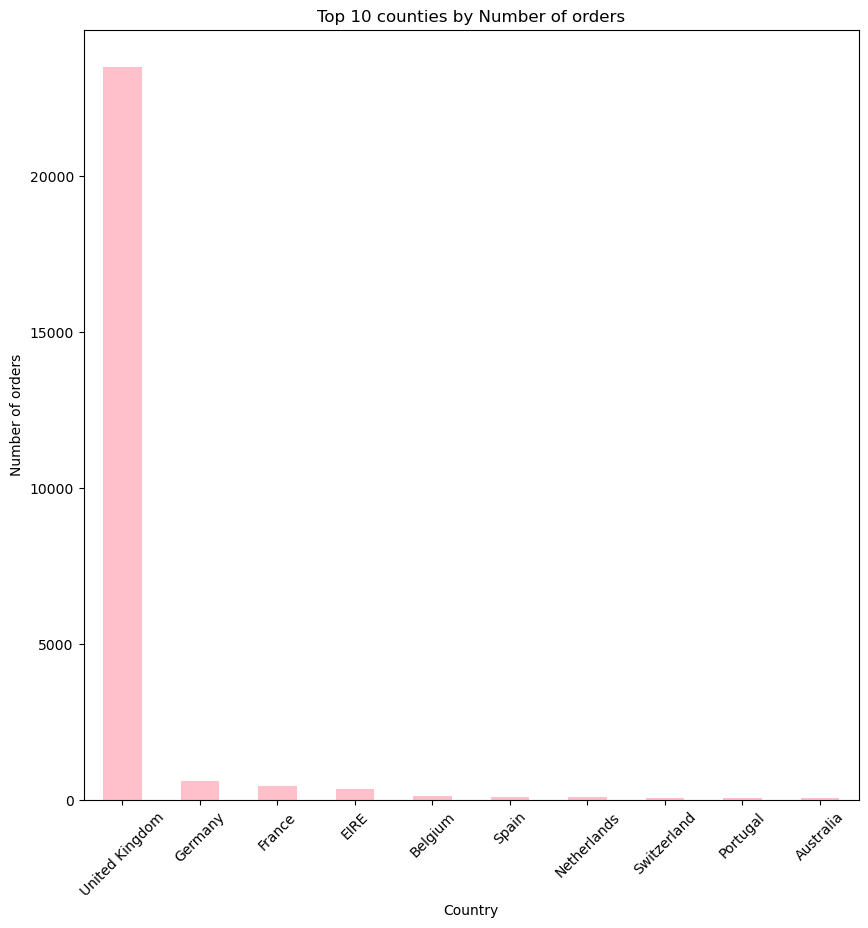

In [73]:
Country_orders=df.groupby("Country")["InvoiceNo"].nunique()
top10_Countries=Country_orders.sort_values(ascending=False).head(10)
print(top10_Countries)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
top10_Countries.plot(kind="bar",color="pink")
plt.xlabel("Country")
plt.ylabel("Number of orders")
plt.title("Top 10 counties by Number of orders")
plt.xticks(rotation=45)
plt.show()

In [ ]:
The business gets most of its customers from the United Kingdom.

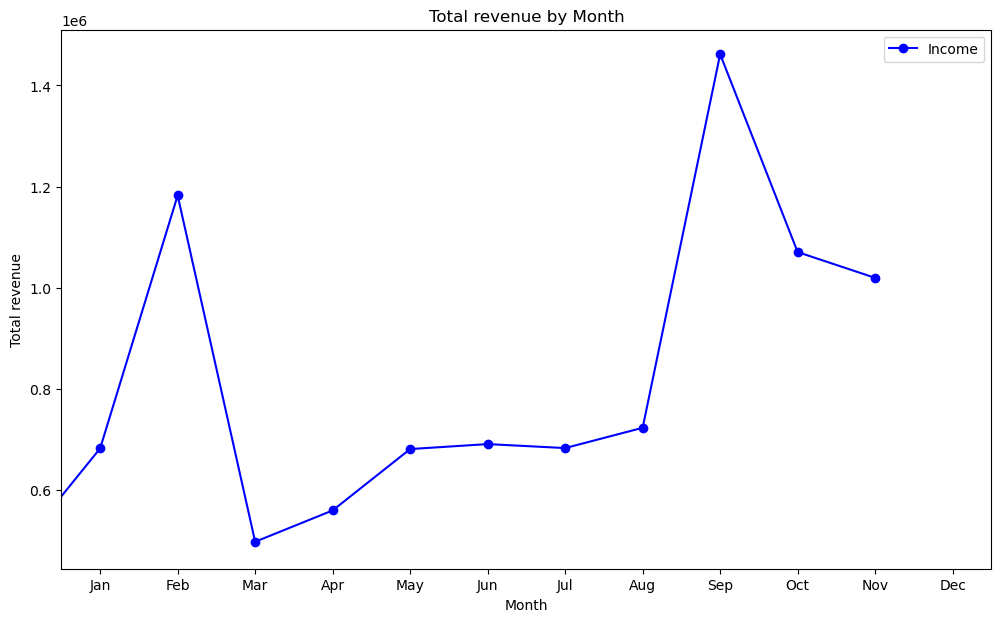

In [61]:
monthly_sales=df.groupby("month")["Income"].sum()

plt.figure(figsize=(12,7))
plt.plot(monthly_sales.index,monthly_sales.values,color="blue",marker="o",label="Income")
months=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
plt.xticks(range(1,13),months)
plt.xlim(0.5,12.5)
plt.title("Total revenue by Month")
plt.xlabel("Month")
plt.ylabel("Total revenue")
plt.legend()
plt.show()

In [ ]:
There is no clear seasonal pattern in this business as both peaks are gotten in different seasons with the highest being in September.

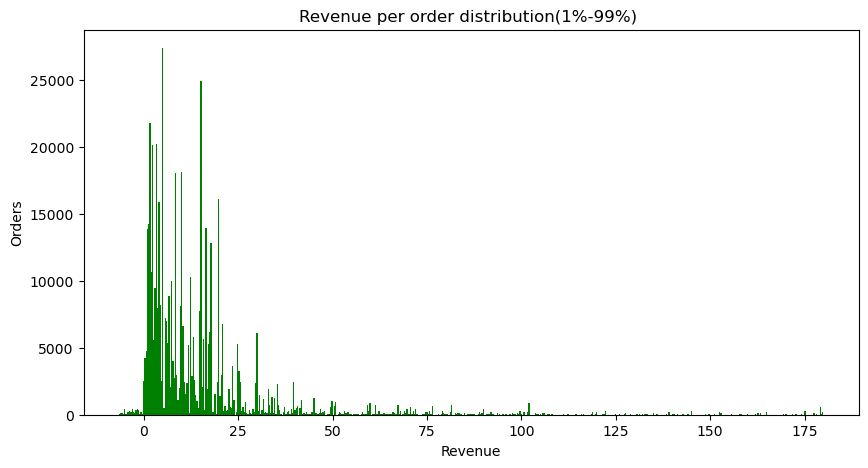

In [64]:
clean_revenue=df[(df["Income"]>=df["Income"].quantile(0.01)) & (df["Income"]<=df["Income"].quantile(0.99))]["Income"]
plt.figure(figsize=(10,5))
plt.hist(clean_revenue,bins="auto",color="green")
plt.title("Revenue per order distribution(1%-99%) ")
plt.xlabel("Revenue")
plt.ylabel("Orders")
plt.show()

In [ ]:
Most orders bring in a small amount of money. A few customers spend much more, which pulls the distribution to the right. Overall, most customers tend to be low to medium spenders.

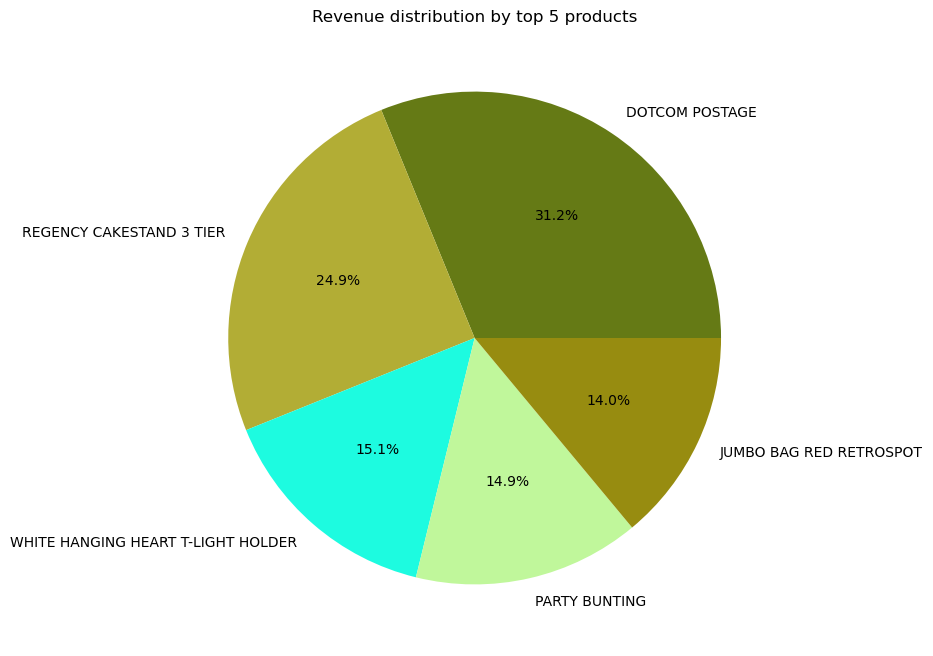

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import random

Description_revenue=df.groupby("Description")["Income"].sum()
Top_Description=Description_revenue.sort_values(ascending=False).head(5)
colors=["#"+"".join(random.choices("0123456789ABCDEF",k=6))
        for i in range(len(Top_Description))]
plt.figure(figsize=(8,8))
plt.pie(Top_Description,labels=Top_Description.index,autopct="%1.1f%%",colors=colors)
plt.title("Revenue distribution by top 5 products")
plt.show()

In [ ]:
DOTCOM POSTAGE is very important product to the business. its revenue percentage shows thats it brings in the highest income

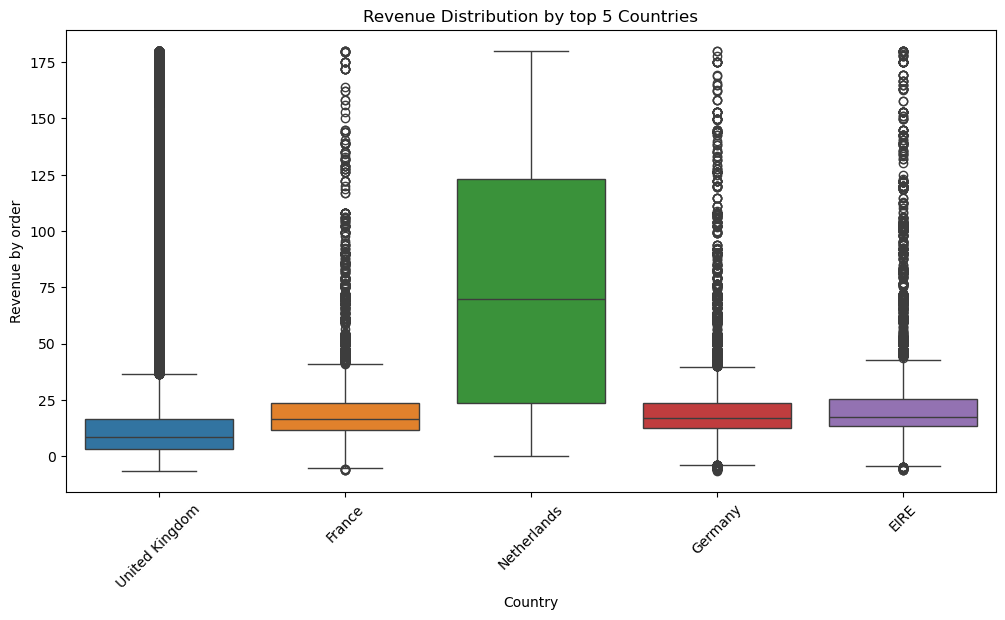

In [71]:
import seaborn as sns
clean_Income=df[(df["Income"]>=df["Income"].quantile(0.01)) & (df["Income"]<=df["Income"].quantile(0.99))]
Top_Countries=clean_Income.groupby("Country")["Income"].sum().nlargest(5).index
plt.figure(figsize=(12,6))
sns.boxplot(data=clean_Income[clean_Income["Country"].isin(Top_Countries)], x="Country",y="Income",hue="Country")
plt.title("Revenue Distribution by top 5 Countries")
plt.xlabel("Country")
plt.ylabel("Revenue by order")
plt.xticks(rotation=45)
plt.show()

In [ ]:
This visualization helps focus on the most meaningful revenue patterns by removing extreme values that could distort the analysis. It highlights the top five countries that generate the most revenue, making it easier to see where the business gains the most value. By showing how revenue is distributed within these key markets, it supports better decisions around market focus, pricing, risk, and resource allocation. Overall, it helps identify where business efforts are most likely to have the greatest impact.


In [ ]:
# Insights 1.
Too much reliance on a few markets
Most of the revenue comes from just five countries. This is risky because any problem in these markets could strongly affect the whole business.

In [ ]:
#Insights 2:
Extreme orders can be misleading
Very large or very small orders can distort the analysis. Removing them gives a clearer and more realistic picture of normal, repeat business.

In [ ]:
# Insight 3:
Markets are at different stages
Some countries show steady and predictable spending, while others vary a lot. This suggests that some markets are well established, while others are still developing or unstable.

In [ ]:
# Insight 4:
Room to grow in other countries
Beyond the top five, there are other countries bringing in revenue that could be developed further instead of relying only on the main markets.

In [ ]:
# Insight 5:
Spending habits differ by country
Customers spend differently depending on the country. This creates opportunities to adjust pricing, design country-specific offers, and encourage customers to spend more.

In [ ]:
Q14: The business should overwhelmingly focus resources on the United Kingdom market. With 23,494 orders compared to Germany's 603 (a 39x difference), the UK represents 92.3% of your top 10 markets' total volume, demonstrating exceptional product-market fit and operational efficiency. While diversification typically reduces risk, the massive gap suggests that resources invested in growing smaller markets would generate significantly lower ROI compared to further penetrating the UK market. The recommended strategy is to allocate 80% of resources to UK growth and retention, 15% to maintaining performance in Germany, France, and Ireland, and only 5% to testing expansion opportunities - essentially treating the UK as your primary growth engine while cautiously maintaining secondary market presence.

In [ ]:
Q15: Based on your monthly sales data showing November as peak sales and April as the lowest, the business should launch its biggest promotions in October to amplify the natural November sales surge (likely holiday-driven), while avoiding major promotional spend during the March-May decline when ROI will be poor. For operations, begin ramping up inventory and temporary staffing in September to prepare for the October-November peak season, then scale down to lean operations from February through May when April hits the annual low. This seasonal pattern suggests a clear Q4 holiday-driven demand cycle that requires strategic resource allocation - investing heavily in the proven November peak while maintaining minimal overhead during the predictable April trough to optimize both revenue capture and operational efficiency.

In [ ]:
Q16: I advise the business to discontinue the worst performers and redirect resources toward expanding inventory of proven winners like your top 5 products or developing variations of them, using both sales volume and profit margin data to make these decisions.

In [ ]:
Q17: Focus aggressively on the UK market during the October-November peak season. 

The data overwhelmingly supports this recommendation: The UK generates 92.3% of your top market orders (23,494 vs. Germany's 603), representing a 39x larger customer base than your second-best market. Combined with November being your peak sales month, there's a massive opportunity to maximize revenue by concentrating resources where you already have proven success. Instead of spreading thin across multiple countries or trying to revive underperforming products, double down on UK customer acquisition, retention, and upselling during your natural peak season. This strategy leverages your strongest market (UK dominance) during your strongest time period (November peak) for maximum revenue impact with the highest probability of success.


In [ ]:
Recommendation 1: Focus 80% of marketing and operational resources on the UK market during September-November preparation and peak season. The data shows UK generates 23,494 orders (39x more than Germany's 603) representing 92.3% of top market volume, combined with November being the peak sales month - maximizing investment where you have proven dominance during natural high-demand periods.

In [ ]:
Recommendation 2: Launch major promotional campaigns in October to amplify the November sales surge, while reducing promotional spend during the March-May decline. Monthly sales data shows November as peak revenue month and April as lowest, indicating a clear seasonal pattern where October promotions can capitalize on natural holiday-driven demand momentum.

In [ ]:
Recommendation 3: Discontinue bottom-performing products and expand inventory of your top 5 bestsellers, particularly "WORLD WAR 2 GLIDERS" (53,751 units) and "JUMBO BAG RED RETROSPOT" (47,260 units). Product performance data shows massive volume gaps between winners and losers - reallocating resources from underperformers to proven bestsellers will improve inventory turnover and reduce carrying costs while meeting demonstrated customer demand.